# Data Cleaning

In [4]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install pathlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install openpyxl

^C
ERROR: Operation cancelled by user
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
from pathlib import Path

raw_path = Path("Korean pbr per")

files = sorted(raw_path.glob("kospi_per_pbr_dividend_*.xlsx"))

print("Files found:")
for file in files:
    print(file.name)

Files found:
kospi_per_pbr_dividend_2010_2011.xlsx
kospi_per_pbr_dividend_2012_2013.xlsx
kospi_per_pbr_dividend_2014_2015.xlsx
kospi_per_pbr_dividend_2016_2017.xlsx
kospi_per_pbr_dividend_2018_2019.xlsx
kospi_per_pbr_dividend_2020_2021.xlsx
kospi_per_pbr_dividend_2021_2023.xlsx
kospi_per_pbr_dividend_2024_2025.xlsx


In [9]:
dfs = []

for file in files:
    df = pd.read_excel(file)
    df["source_file"] = file.name
    dfs.append(df)

kospi_raw = pd.concat(dfs, ignore_index=True)

kospi_raw.head()

/home/jupyter-smsorokina@edu.hse-4bc37/.local/lib/python3.8/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/jupyter-smsorokina@edu.hse-4bc37/.local/lib/python3.8/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/jupyter-smsorokina@edu.hse-4bc37/.local/lib/python3.8/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/jupyter-smsorokina@edu.hse-4bc37/.local/lib/python3.8/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openp

,Date,Close,Change,%Change,PER,PBR,Dividend yield,source_file
0,2011/12/29,1825.74,0.62,0.03,10.90,1.19,1.54,kospi_per_pbr_dividend_2010_2011.xlsx
1,2011/12/28,1825.12,-16.90,-0.92,10.89,1.19,1.54,kospi_per_pbr_dividend_2010_2011.xlsx
2,2011/12/27,1842.02,-14.68,-0.79,11.00,1.20,1.53,kospi_per_pbr_dividend_2010_2011.xlsx
3,2011/12/26,1856.70,-10.52,-0.56,11.09,1.21,1.52,kospi_per_pbr_dividend_2010_2011.xlsx
4,2011/12/23,1867.22,19.73,1.07,11.15,1.22,1.51,kospi_per_pbr_dividend_2010_2011.xlsx


In [10]:
kospi = kospi_raw.copy()

kospi = kospi.rename(columns={
    "Date": "date",
    "Close": "close",
    "Change": "change",
    "%Change": "pct_change",
    "PER": "per",
    "PBR": "pbr",
    "Dividend yield": "dividend_yield"
})

kospi.head()

,date,close,change,pct_change,per,pbr,dividend_yield,source_file
0,2011/12/29,1825.74,0.62,0.03,10.90,1.19,1.54,kospi_per_pbr_dividend_2010_2011.xlsx
1,2011/12/28,1825.12,-16.90,-0.92,10.89,1.19,1.54,kospi_per_pbr_dividend_2010_2011.xlsx
2,2011/12/27,1842.02,-14.68,-0.79,11.00,1.20,1.53,kospi_per_pbr_dividend_2010_2011.xlsx
3,2011/12/26,1856.70,-10.52,-0.56,11.09,1.21,1.52,kospi_per_pbr_dividend_2010_2011.xlsx
4,2011/12/23,1867.22,19.73,1.07,11.15,1.22,1.51,kospi_per_pbr_dividend_2010_2011.xlsx


In [11]:
kospi["date"] = pd.to_datetime(kospi["date"], errors="coerce")

numeric_cols = ["close", "change", "pct_change", "per", "pbr", "dividend_yield"]

for col in numeric_cols:
    kospi[col] = pd.to_numeric(kospi[col], errors="coerce")

kospi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3939 entries, 0 to 3938
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            3939 non-null   datetime64[ns]
 1   close           3939 non-null   float64       
 2   change          3939 non-null   float64       
 3   pct_change      3939 non-null   float64       
 4   per             3939 non-null   float64       
 5   pbr             3939 non-null   float64       
 6   dividend_yield  3939 non-null   float64       
 7   source_file     3939 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 246.3+ KB


In [12]:
kospi = kospi.dropna(subset=["date"])

kospi = kospi.drop_duplicates()

kospi = kospi.sort_values(["date", "source_file"])
kospi = kospi.drop_duplicates(subset=["date"], keep="first")

kospi = kospi.sort_values("date").reset_index(drop=True)

kospi.head(), kospi.tail()

(        date    close  change  pct_change    per   pbr  dividend_yield  \
 0 2010-01-04  1696.14   13.37        0.79  23.87  1.35            1.16   
 1 2010-01-05  1690.62   -5.52       -0.33  23.80  1.35            1.17   
 2 2010-01-06  1705.32   14.70        0.87  24.01  1.36            1.16   
 3 2010-01-07  1683.45  -21.87       -1.28  23.71  1.34            1.17   
 4 2010-01-08  1695.26   11.81        0.70  23.88  1.35            1.16   
 
                              source_file  
 0  kospi_per_pbr_dividend_2010_2011.xlsx  
 1  kospi_per_pbr_dividend_2010_2011.xlsx  
 2  kospi_per_pbr_dividend_2010_2011.xlsx  
 3  kospi_per_pbr_dividend_2010_2011.xlsx  
 4  kospi_per_pbr_dividend_2010_2011.xlsx  ,
            date    close  change  pct_change    per   pbr  dividend_yield  \
 3934 2025-12-23  4117.32   11.39        0.28  17.15  1.32            1.33   
 3935 2025-12-24  4108.62   -8.70       -0.21  17.12  1.32            1.34   
 3936 2025-12-26  4129.68   21.06        0.51  17

In [13]:
missing_percent = (kospi.isna().mean() * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": kospi.isna().sum(),
    "missing_percent": missing_percent
})

missing_table

,missing_count,missing_percent
date,0,0.0
close,0,0.0
change,0,0.0
pct_change,0,0.0
per,0,0.0
pbr,0,0.0
dividend_yield,0,0.0
source_file,0,0.0


In [14]:
duplicate_dates = kospi[kospi.duplicated(subset=["date"], keep=False)]

duplicate_dates.sort_values("date")

,date,close,change,pct_change,per,pbr,dividend_yield,source_file


In [15]:
kospi["year"] = kospi["date"].dt.year

yearly_coverage = (
    kospi
    .groupby("year")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        observations=("date", "count"),
        mean_pbr=("pbr", "mean"),
        mean_per=("per", "mean"),
        mean_dividend_yield=("dividend_yield", "mean")
    )
    .reset_index()
)

yearly_coverage

,year,start_date,end_date,observations,mean_pbr,mean_per,mean_dividend_yield
0,2010,2010-01-04,2010-12-30,251,1.331713,18.296693,1.235020
1,2011,2011-01-03,2011-12-29,248,1.349355,13.640685,1.337379
2,2012,2012-01-02,2012-12-28,248,1.225524,12.258387,1.406573
3,2013,2013-01-02,2013-12-30,247,1.182915,13.454332,1.244332
4,2014,2014-01-02,2014-12-30,245,1.144735,15.299796,1.123347
5,2015,2015-01-02,2015-12-30,248,1.136290,16.140685,1.230726
6,2016,2016-01-04,2016-12-29,246,1.053211,14.346789,1.528659
7,2017,2017-01-02,2017-12-28,243,1.098519,14.284239,1.418724
8,2018,2018-01-02,2018-12-28,244,1.044221,11.549713,1.602377
9,2019,2019-01-02,2019-12-30,246,0.884959,12.259553,2.035447


In [16]:
output_path = Path("data_clean")
output_path.mkdir(exist_ok=True)

kospi.to_csv(output_path / "kospi_per_pbr_dividend_2010_2025_clean.csv", index=False)

kospi.to_excel(output_path / "kospi_per_pbr_dividend_2010_2025_clean.xlsx", index=False)

# Descriptive statistics

In [17]:
kospi_monthly = (
    kospi
    .set_index("date")
    .resample("M")
    .agg({
        "close": "last",
        "per": "mean",
        "pbr": "mean",
        "dividend_yield": "mean",
        "pct_change": "mean"
    })
    .reset_index()
)

kospi_monthly.head()

,date,close,per,pbr,dividend_yield,pct_change
0,2010-01-31,1602.43,23.641500,1.343000,1.173000,-0.238500
1,2010-02-28,1594.58,22.750000,1.277895,1.231579,-0.017368
2,2010-03-31,1692.85,23.793182,1.334091,1.176364,0.273636
3,2010-04-30,1741.56,23.518636,1.375000,1.145000,0.132727
4,2010-05-31,1641.25,14.775789,1.218421,1.353684,-0.300526


In [18]:
kospi_monthly.to_csv(output_path / "kospi_monthly_2010_2025.csv", index=False)
kospi_monthly.to_excel(output_path / "kospi_monthly_2010_2025.xlsx", index=False)

In [38]:
kospi_yearly = (
    kospi
    .groupby(kospi["date"].dt.year)
    .agg(
        mean_close=("close", "mean"),
        year_end_close=("close", "last"),
        mean_per=("per", "mean"),
        median_per=("per", "median"),
        mean_pbr=("pbr", "mean"),
        median_pbr=("pbr", "median"),
        mean_dividend_yield=("dividend_yield", "mean"),
        observations=("date", "count")
    )
    .reset_index()
    .rename(columns={"date": "year"})
)

kospi_yearly

,year,mean_close,year_end_close,mean_per,median_per,mean_pbr,median_pbr,mean_dividend_yield,observations
0,2010,1764.993506,2051.00,18.296693,16.450,1.331713,1.330,1.235020,251
1,2011,1983.419677,1825.74,13.640685,12.705,1.349355,1.380,1.337379,248
2,2012,1930.372702,1997.05,12.258387,12.280,1.225524,1.220,1.406573,248
3,2013,1960.499717,2011.34,13.454332,13.200,1.182915,1.190,1.244332,247
4,2014,1982.158122,1915.59,15.299796,15.370,1.144735,1.150,1.123347,245
5,2015,2011.848750,1961.31,16.140685,15.840,1.136290,1.130,1.230726,248
6,2016,1987.003252,2026.46,14.346789,14.180,1.053211,1.060,1.528659,246
7,2017,2311.357490,2467.49,14.284239,14.340,1.098519,1.110,1.418724,243
8,2018,2325.009426,2041.04,11.549713,11.125,1.044221,1.040,1.602377,244
9,2019,2106.053577,2197.67,12.259553,11.515,0.884959,0.880,2.035447,246


In [39]:
kospi_yearly.to_csv(output_path / "kospi_yearly_2010_2025.csv", index=False)
kospi_yearly.to_excel(output_path / "kospi_yearly_2010_2025.xlsx", index=False)

In [21]:
desc_stats = kospi[["close", "per", "pbr", "dividend_yield"]].describe().T

desc_stats = desc_stats.rename(columns={
    "count": "N",
    "mean": "Mean",
    "std": "Std. Dev.",
    "min": "Min",
    "25%": "25th percentile",
    "50%": "Median",
    "75%": "75th percentile",
    "max": "Max"
})

desc_stats

,N,Mean,Std. Dev.,Min,25th percentile,Median,75th percentile,Max
close,3939.0,2276.961896,437.108648,1457.64,1974.66,2120.08,2501.32,4221.87
per,3939.0,15.360939,4.523374,9.26,12.62,14.42,16.66,33.35
pbr,3939.0,1.095981,0.163027,0.59,0.96,1.11,1.20,1.63
dividend_yield,3939.0,1.587619,0.343749,1.00,1.31,1.52,1.88,3.03


In [22]:
desc_stats.to_excel(output_path / "descriptive_statistics_kospi.xlsx")

# pre-Value Up and post-Value Up

In [23]:
kospi["value_up_period"] = kospi["date"].apply(
    lambda x: "Post-Value-Up" if x >= pd.Timestamp("2024-01-24") else "Pre-Value-Up"
)

value_up_desc = (
    kospi
    .groupby("value_up_period")
    .agg(
        observations=("date", "count"),
        mean_close=("close", "mean"),
        mean_per=("per", "mean"),
        median_per=("per", "median"),
        mean_pbr=("pbr", "mean"),
        median_pbr=("pbr", "median"),
        mean_dividend_yield=("dividend_yield", "mean")
    )
    .reset_index()
)

value_up_desc

,value_up_period,observations,mean_close,mean_per,median_per,mean_pbr,median_pbr,mean_dividend_yield
0,Post-Value-Up,470,2883.585745,16.251468,14.915,1.002021,0.97,1.810149
1,Pre-Value-Up,3469,2194.773021,15.240285,14.320,1.108711,1.12,1.557469


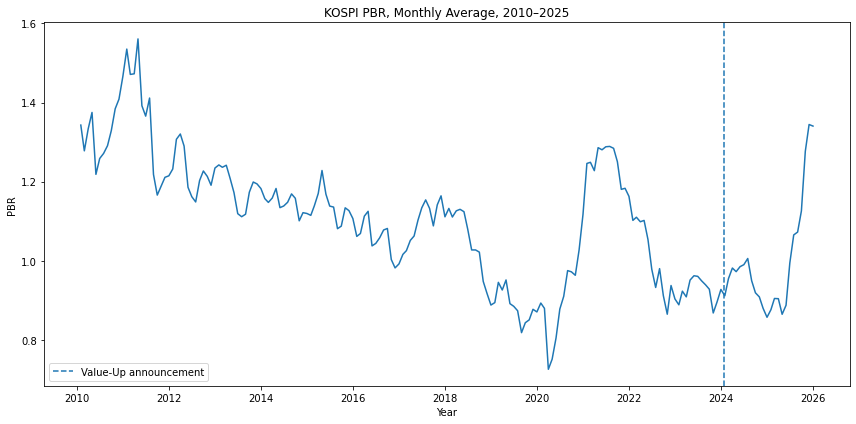

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(kospi_monthly["date"], kospi_monthly["pbr"])

plt.axvline(pd.Timestamp("2024-01-24"), linestyle="--", label="Value-Up announcement")

plt.title("KOSPI PBR, Monthly Average, 2010–2025")
plt.xlabel("Year")
plt.ylabel("PBR")
plt.legend()
plt.tight_layout()

plt.savefig(output_path / "kospi_pbr_monthly_2010_2025.png", dpi=300)
plt.show()

# Japan

In [25]:
raw_file = Path("japan_per_pbr_not_cleaned.xlsx")
output_path = Path("data_clean")
output_path.mkdir(exist_ok=True)

def clean_numeric(series):
     
    return pd.to_numeric(
        series.replace({
            "-": pd.NA,
            "－": pd.NA,
            "＊": pd.NA,
            "*": pd.NA,
            "": pd.NA
        }),
        errors="coerce"
    )

In [26]:
pre_sheet = "Consolidated(AVG)～202203"

pre_raw = pd.read_excel(
    raw_file,
    sheet_name=pre_sheet,
    header=None,
    skiprows=4
)

japan_pre = pre_raw.iloc[:, [0, 1, 7, 8, 9, 10, 11]].copy()

japan_pre.columns = [
    "year",
    "month",
    "no_companies",
    "per",
    "pbr",
    "eps",
    "bps"
]

japan_pre["year"] = pd.to_numeric(japan_pre["year"], errors="coerce")
japan_pre["month"] = pd.to_numeric(japan_pre["month"], errors="coerce")

japan_pre = japan_pre.dropna(subset=["year", "month"])

japan_pre["year"] = japan_pre["year"].astype(int)
japan_pre["month"] = japan_pre["month"].astype(int)

japan_pre = japan_pre[japan_pre["month"].between(1, 12)]

for col in ["no_companies", "per", "pbr", "eps", "bps"]:
    japan_pre[col] = clean_numeric(japan_pre[col])

japan_pre["date"] = pd.to_datetime(
    japan_pre[["year", "month"]].assign(day=1)
)

japan_pre["country"] = "Japan"
japan_pre["market_section"] = "TSE First Section"
japan_pre["accounting_basis"] = "Consolidated"
japan_pre["aggregation_method"] = "Average"

japan_pre = japan_pre[
    (japan_pre["date"] >= "2010-01-01") &
    (japan_pre["date"] <= "2022-03-01")
]

japan_pre.head()

,year,month,no_companies,per,pbr,eps,bps,date,country,market_section,accounting_basis,aggregation_method
132,2010,1,1672,NaN,0.9,-1.71,280.08,2010-01-01,Japan,TSE First Section,Consolidated,Average
133,2010,2,1670,NaN,0.9,-1.87,280.13,2010-02-01,Japan,TSE First Section,Consolidated,Average
134,2010,3,1658,NaN,1.0,-1.74,277.94,2010-03-01,Japan,TSE First Section,Consolidated,Average
135,2010,4,1661,NaN,1.0,-1.82,276.10,2010-04-01,Japan,TSE First Section,Consolidated,Average
136,2010,5,1660,NaN,0.9,-1.82,276.64,2010-05-01,Japan,TSE First Section,Consolidated,Average


In [27]:
post_sheet = "Consolidated(Average)"

post_raw = pd.read_excel(
    raw_file,
    sheet_name=post_sheet,
    header=None,
    skiprows=4
)

japan_post = post_raw.iloc[:, [0, 1, 2, 3, 4, 5, 6]].copy()

japan_post.columns = [
    "year",
    "month",
    "no_companies",
    "per",
    "pbr",
    "eps",
    "bps"
]

japan_post["year"] = pd.to_numeric(japan_post["year"], errors="coerce")
japan_post["month"] = pd.to_numeric(japan_post["month"], errors="coerce")

japan_post = japan_post.dropna(subset=["year", "month"])

japan_post["year"] = japan_post["year"].astype(int)
japan_post["month"] = japan_post["month"].astype(int)

japan_post = japan_post[japan_post["month"].between(1, 12)]

for col in ["no_companies", "per", "pbr", "eps", "bps"]:
    japan_post[col] = clean_numeric(japan_post[col])

japan_post["date"] = pd.to_datetime(
    japan_post[["year", "month"]].assign(day=1)
)

japan_post["country"] = "Japan"
japan_post["market_section"] = "Prime Section"
japan_post["accounting_basis"] = "Consolidated"
japan_post["aggregation_method"] = "Average"

japan_post = japan_post[
    (japan_post["date"] >= "2022-04-01") &
    (japan_post["date"] <= "2025-12-01")
]

japan_post.head()

,year,month,no_companies,per,pbr,eps,bps,date,country,market_section,accounting_basis,aggregation_method
0,2022,4,1821,20.4,1.2,118.12,2002.61,2022-04-01,Japan,Prime Section,Consolidated,Average
1,2022,5,1822,19.8,1.2,121.92,2008.56,2022-05-01,Japan,Prime Section,Consolidated,Average
2,2022,6,1833,13.7,1.1,172.63,2127.92,2022-06-01,Japan,Prime Section,Consolidated,Average
3,2022,7,1832,14.4,1.2,172.06,2125.67,2022-07-01,Japan,Prime Section,Consolidated,Average
4,2022,8,1831,14.6,1.2,172.01,2127.57,2022-08-01,Japan,Prime Section,Consolidated,Average


In [28]:
japan = pd.concat([japan_pre, japan_post], ignore_index=True)

japan = japan.sort_values("date").reset_index(drop=True)

japan = japan[
    [
        "date",
        "year",
        "month",
        "country",
        "market_section",
        "accounting_basis",
        "aggregation_method",
        "no_companies",
        "per",
        "pbr",
        "eps",
        "bps"
    ]
]

japan

,date,year,month,country,market_section,accounting_basis,aggregation_method,no_companies,per,pbr,eps,bps
0,2010-01-01,2010,1,Japan,TSE First Section,Consolidated,Average,1672,NaN,0.9,-1.71,280.08
1,2010-02-01,2010,2,Japan,TSE First Section,Consolidated,Average,1670,NaN,0.9,-1.87,280.13
2,2010-03-01,2010,3,Japan,TSE First Section,Consolidated,Average,1658,NaN,1.0,-1.74,277.94
3,2010-04-01,2010,4,Japan,TSE First Section,Consolidated,Average,1661,NaN,1.0,-1.82,276.10
4,2010-05-01,2010,5,Japan,TSE First Section,Consolidated,Average,1660,NaN,0.9,-1.82,276.64
...,...,...,...,...,...,...,...,...,...,...,...,...
187,2025-08-01,2025,8,Japan,Prime Section,Consolidated,Average,1614,16.8,1.3,176.10,2234.75
188,2025-09-01,2025,9,Japan,Prime Section,Consolidated,Average,1607,17.0,1.3,170.14,2159.82
189,2025-10-01,2025,10,Japan,Prime Section,Consolidated,Average,1608,17.5,1.4,170.21,2158.44
190,2025-11-01,2025,11,Japan,Prime Section,Consolidated,Average,1597,17.9,1.4,171.30,2164.53


In [29]:
japan_coverage = (
    japan
    .groupby("year")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        observations=("date", "count"),
        mean_per=("per", "mean"),
        mean_pbr=("pbr", "mean")
    )
    .reset_index()
)

japan_coverage

,year,start_date,end_date,observations,mean_per,mean_pbr
0,2010,2010-01-01,2010-12-01,12,31.985714,0.866667
1,2011,2011-01-01,2011-12-01,12,21.650000,0.816667
2,2012,2012-01-01,2012-12-01,12,16.583333,0.766667
3,2013,2013-01-01,2013-12-01,12,21.666667,1.033333
4,2014,2014-01-01,2014-12-01,12,19.383333,1.108333
5,2015,2015-01-01,2015-12-01,12,19.016667,1.216667
6,2016,2016-01-01,2016-12-01,12,17.166667,1.050000
7,2017,2017-01-01,2017-12-01,12,20.075000,1.266667
8,2018,2018-01-01,2018-12-01,12,18.766667,1.333333
9,2019,2019-01-01,2019-12-01,12,16.200000,1.150000


In [30]:
missing_table = pd.DataFrame({
    "missing_count": japan.isna().sum(),
    "missing_percent": (japan.isna().mean() * 100).round(2)
})

missing_table

,missing_count,missing_percent
date,0,0.0
year,0,0.0
month,0,0.0
country,0,0.0
market_section,0,0.0
accounting_basis,0,0.0
aggregation_method,0,0.0
no_companies,0,0.0
per,5,2.6
pbr,0,0.0


In [31]:
japan.to_csv(output_path / "japan_per_pbr_2010_2025_clean.csv", index=False)
japan.to_excel(output_path / "japan_per_pbr_2010_2025_clean.xlsx", index=False)

In [32]:
japan_desc = japan[["per", "pbr", "eps", "bps"]].describe().T

japan_desc = japan_desc.rename(columns={
    "count": "N",
    "mean": "Mean",
    "std": "Std. Dev.",
    "min": "Min",
    "25%": "25th percentile",
    "50%": "Median",
    "75%": "75th percentile",
    "max": "Max"
})

japan_desc

,N,Mean,Std. Dev.,Min,25th percentile,Median,75th percentile,Max
per,187.0,19.268984,4.304411,13.70,16.3500,17.900,20.9500,33.60
pbr,192.0,1.121875,0.183168,0.70,1.0000,1.200,1.2000,1.50
eps,192.0,71.242396,67.068768,-1.87,13.9675,17.115,138.3700,178.11
bps,192.0,1066.336562,891.800588,193.95,274.6550,285.535,1936.4575,2326.75


In [33]:
japan_yearly = (
    japan
    .groupby("year")
    .agg(
        mean_per=("per", "mean"),
        median_per=("per", "median"),
        mean_pbr=("pbr", "mean"),
        median_pbr=("pbr", "median"),
        mean_eps=("eps", "mean"),
        mean_bps=("bps", "mean"),
        observations=("date", "count")
    )
    .reset_index()
)

japan_yearly

,year,mean_per,median_per,mean_pbr,median_pbr,mean_eps,mean_bps,observations
0,2010,31.985714,31.80,0.866667,0.85,3.435000,282.016667,12
1,2011,21.650000,16.75,0.816667,0.80,11.617500,281.381667,12
2,2012,16.583333,16.45,0.766667,0.80,13.399167,282.126667,12
3,2013,21.666667,21.80,1.033333,1.05,13.774167,288.080000,12
4,2014,19.383333,18.35,1.108333,1.10,15.760833,274.222500,12
5,2015,19.016667,18.90,1.216667,1.20,16.927500,266.809167,12
6,2016,17.166667,16.90,1.050000,1.00,15.300833,248.081667,12
7,2017,20.075000,20.00,1.266667,1.20,14.152500,222.825000,12
8,2018,18.766667,18.25,1.333333,1.35,45.465833,622.680000,12
9,2019,16.200000,16.05,1.150000,1.15,134.910833,1887.869167,12


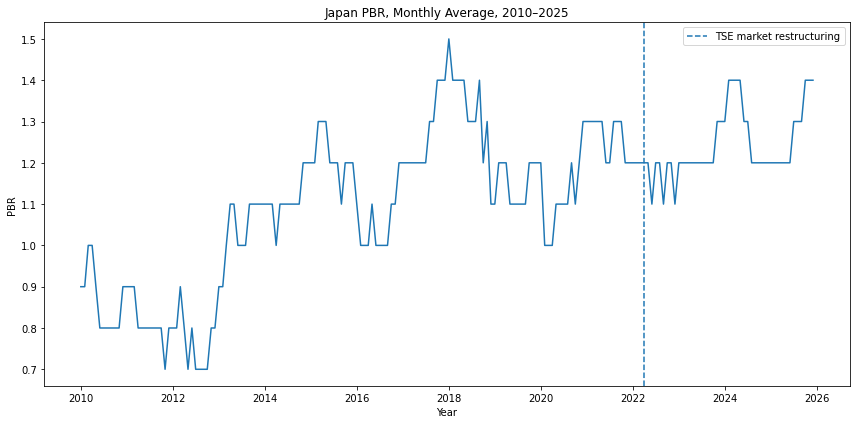

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(japan["date"], japan["pbr"])

plt.axvline(pd.Timestamp("2022-04-01"), linestyle="--", label="TSE market restructuring")

plt.title("Japan PBR, Monthly Average, 2010–2025")
plt.xlabel("Year")
plt.ylabel("PBR")
plt.legend()
plt.tight_layout()

plt.savefig(output_path / "japan_pbr_monthly_2010_2025.png", dpi=300)
plt.show()

In [35]:
korea_com= pd.read_csv("data_clean/kospi_monthly_2010_2025.csv")

japan_com = pd.read_csv("data_clean/japan_per_pbr_2010_2025_clean.csv")

korea_com["date"] = pd.to_datetime(korea_com["date"]).dt.to_period("M").dt.to_timestamp()
japan_com["date"] = pd.to_datetime(japan_com["date"]).dt.to_period("M").dt.to_timestamp()

korea_panel = korea_com.copy()
korea_panel["country"] = "Korea"

korea_panel = korea_panel[["date", "country", "per", "pbr"]]
japan_panel = japan_com[["date", "country", "per", "pbr"]]

korea_japan_panel = pd.concat([korea_panel, japan_panel], ignore_index=True)

korea_japan_panel = korea_japan_panel.sort_values(["country", "date"]).reset_index(drop=True)

korea_japan_panel

,date,country,per,pbr
0,2010-01-01,Japan,NaN,0.900000
1,2010-02-01,Japan,NaN,0.900000
2,2010-03-01,Japan,NaN,1.000000
3,2010-04-01,Japan,NaN,1.000000
4,2010-05-01,Japan,NaN,0.900000
...,...,...,...,...
379,2025-08-01,Korea,14.564500,1.072500
380,2025-09-01,Korea,15.414545,1.125909
381,2025-10-01,Korea,17.586111,1.276667
382,2025-11-01,Korea,18.530500,1.344500


In [36]:
country_desc_clean = (
    korea_japan_panel
    .groupby("country")
    .agg(
        observations=("pbr", "count"),
        mean_per=("per", "mean"),
        median_per=("per", "median"),
        std_per=("per", "std"),
        mean_pbr=("pbr", "mean"),
        median_pbr=("pbr", "median"),
        std_pbr=("pbr", "std"),
        min_pbr=("pbr", "min"),
        max_pbr=("pbr", "max")
    )
    .reset_index()
)

country_desc_clean

,country,observations,mean_per,median_per,std_per,mean_pbr,median_pbr,std_pbr,min_pbr,max_pbr
0,Japan,192,19.268984,17.900000,4.304411,1.121875,1.200000,0.183168,0.700000,1.500000
1,Korea,192,15.358672,14.441126,4.496178,1.095278,1.111178,0.161606,0.725455,1.560952


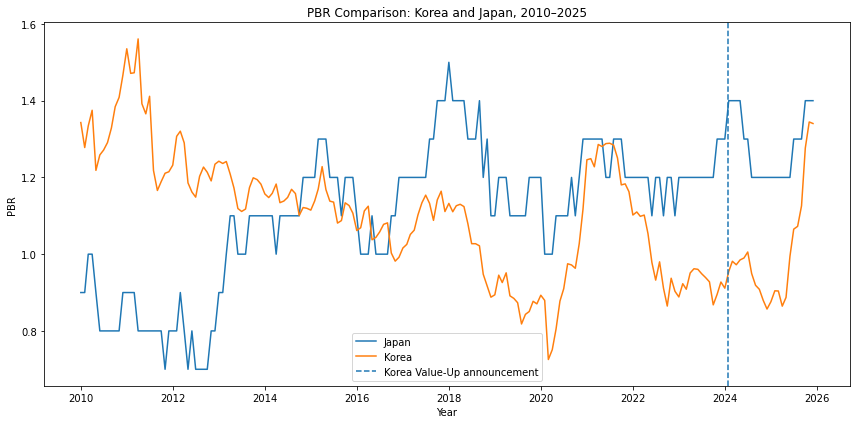

In [37]:
plt.figure(figsize=(12, 6))

for country in korea_japan_panel["country"].unique():
    subset = korea_japan_panel[korea_japan_panel["country"] == country]
    plt.plot(subset["date"], subset["pbr"], label=country)

plt.axvline(pd.Timestamp("2024-01-24"), linestyle="--", label="Korea Value-Up announcement")

plt.title("PBR Comparison: Korea and Japan, 2010–2025")
plt.xlabel("Year")
plt.ylabel("PBR")
plt.legend()
plt.tight_layout()

plt.show()

# Taiwan

In [1]:
import zipfile
import re
import io
from pathlib import Path

import pandas as pd
from pandas.errors import EmptyDataError

In [2]:
zip_path = Path("TAIEX_pbr_per.zip")

output_path = Path("data_clean")
output_path.mkdir(exist_ok=True)

In [3]:
records = []
failed_files = []
all_dfs = []

with zipfile.ZipFile(zip_path) as z:
    file_names = sorted([
        name for name in z.namelist()
        if name.lower().endswith(".csv")
    ])

    print("Number of CSV files found:", len(file_names))

    for name in file_names:
        file_short_name = Path(name).name

        date_match = re.search(r"(\d{8})\.csv$", file_short_name)

        if date_match is None:
            failed_files.append({
                "file": file_short_name,
                "date": None,
                "reason": "No date found in filename"
            })
            continue

        date = pd.to_datetime(date_match.group(1), format="%Y%m%d")

        file_data = z.read(name)

        try:
            df = pd.read_csv(
                io.BytesIO(file_data),
                skiprows=1,
                encoding="utf-8-sig"
            )

        except EmptyDataError:
            failed_files.append({
                "file": file_short_name,
                "date": date,
                "reason": "Empty or unreadable file"
            })
            continue

        except Exception as e:
            failed_files.append({
                "file": file_short_name,
                "date": date,
                "reason": str(e)
            })
            continue

        df = df.dropna(axis=1, how="all")

        df.columns = [
            str(col).strip().replace("\ufeff", "")
            for col in df.columns
        ]

        df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

        df["date"] = date
        df["source_file"] = file_short_name

        all_dfs.append(df)

        records.append({
            "file": file_short_name,
            "date": date,
            "rows": len(df),
            "columns": " | ".join(df.columns)
        })

print("Successfully read files:", len(all_dfs))
print("Failed files:", len(failed_files))

Number of CSV files found: 192
Successfully read files: 192
Failed files: 0


In [4]:
taiwan_raw = pd.concat(all_dfs, ignore_index=True)

taiwan_raw.head()

,Security Code,P/E ratio,Dividend yield (%),P/B ratio,date,source_file,Closing Price,Dividend year,Fiscal year / quarter
0,1101,16.76,4.33,1.31,2010-01-28,TAIEX_pbr_per_20100128.csv,NaN,NaN,NaN
1,1102,13.04,6.80,1.29,2010-01-28,TAIEX_pbr_per_20100128.csv,NaN,NaN,NaN
2,1103,35.56,0.00,0.68,2010-01-28,TAIEX_pbr_per_20100128.csv,NaN,NaN,NaN
3,1104,65.20,0.00,0.82,2010-01-28,TAIEX_pbr_per_20100128.csv,NaN,NaN,NaN
4,1108,-,0.00,0.76,2010-01-28,TAIEX_pbr_per_20100128.csv,NaN,NaN,NaN


In [5]:
taiwan = taiwan_raw.rename(columns={
    "Security Code": "stock_code",
    "Closing Price": "close",
    "Dividend yield (%)": "dividend_yield",
    "Dividend year": "dividend_year",
    "P/E ratio": "per",
    "P/B ratio": "pbr",
    "Fiscal year / quarter": "fiscal_year_quarter"
})

In [10]:
taiwan

,stock_code,per,dividend_yield,pbr,date,source_file,close,dividend_year,fiscal_year_quarter
0,1101,16.76,4.33,1.31,2010-01-28,TAIEX_pbr_per_20100128.csv,NaN,NaN,NaN
1,1102,13.04,6.80,1.29,2010-01-28,TAIEX_pbr_per_20100128.csv,NaN,NaN,NaN
2,1103,35.56,0.00,0.68,2010-01-28,TAIEX_pbr_per_20100128.csv,NaN,NaN,NaN
3,1104,65.20,0.00,0.82,2010-01-28,TAIEX_pbr_per_20100128.csv,NaN,NaN,NaN
4,1108,-,0.00,0.76,2010-01-28,TAIEX_pbr_per_20100128.csv,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
172110,9944,-,1.76,0.55,2025-12-31,TAIEX_pbr_per_20251231.csv,17.05,2024.0,2025/3
172111,9945,9.00,3.69,0.87,2025-12-31,TAIEX_pbr_per_20251231.csv,29.80,2024.0,2025/3
172112,9946,106.67,5.42,1.01,2025-12-31,TAIEX_pbr_per_20251231.csv,19.20,2024.0,2025/3
172113,9955,-,0.00,2.81,2025-12-31,TAIEX_pbr_per_20251231.csv,30.50,2024.0,2025/3


In [7]:
def clean_number(series):
    return pd.to_numeric(
        series
        .astype(str)
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .replace({
            "-": None,
            "--": None,
            "－": None,
            "": None,
            "nan": None,
            "None": None,
            "N/A": None
        }),
        errors="coerce"
    )

In [11]:
numeric_cols = ["close", "dividend_yield", "per", "pbr"]

for col in numeric_cols:
    if col in taiwan.columns:
        taiwan[col] = clean_number(taiwan[col])

In [12]:
taiwan["date"] = pd.to_datetime(taiwan["date"], errors="coerce")

taiwan["stock_code"] = (
    taiwan["stock_code"]
    .astype(str)
    .str.strip()
)

taiwan["month"] = taiwan["date"].dt.to_period("M").dt.to_timestamp()
taiwan["year"] = taiwan["date"].dt.year

In [13]:
print("Date range:")
print(taiwan["date"].min(), "to", taiwan["date"].max())

print("\nNumber of rows:")
print(len(taiwan))

print("\nMissing values:")
print(taiwan[["per", "pbr", "dividend_yield"]].isna().sum())

Date range:
2010-01-28 00:00:00 to 2025-12-31 00:00:00

Number of rows:
172115

Missing values:
per               33111
pbr                  59
dividend_yield        0
dtype: int64


In [14]:
missing_table = pd.DataFrame({
    "missing_count": taiwan.isna().sum(),
    "missing_percent": (taiwan.isna().mean() * 100).round(2)
})

missing_table

,missing_count,missing_percent
stock_code,0,0.00
per,33111,19.24
dividend_yield,0,0.00
pbr,59,0.03
date,0,0.00
source_file,0,0.00
close,71151,41.34
dividend_year,71151,41.34
fiscal_year_quarter,71151,41.34
month,0,0.00


In [15]:
taiwan_monthly = (
    taiwan
    .groupby("month")
    .agg(
        date_used=("date", "first"),
        observations=("stock_code", "count"),
        valid_per=("per", "count"),
        valid_pbr=("pbr", "count"),
        valid_dividend_yield=("dividend_yield", "count"),
        mean_per=("per", "mean"),
        median_per=("per", "median"),
        mean_pbr=("pbr", "mean"),
        median_pbr=("pbr", "median"),
        mean_dividend_yield=("dividend_yield", "mean"),
        median_dividend_yield=("dividend_yield", "median")
    )
    .reset_index()
)

taiwan_monthly = taiwan_monthly.rename(columns={"month": "date"})
taiwan_monthly["country"] = "Taiwan"

taiwan_monthly.head()

,date,date_used,observations,valid_per,valid_pbr,valid_dividend_yield,mean_per,median_per,mean_pbr,median_pbr,mean_dividend_yield,median_dividend_yield,country
0,2010-01-01,2010-01-28,739,478,739,739,55.900356,20.320,1.904452,1.450,2.358647,1.860,Taiwan
1,2010-02-01,2010-02-26,741,479,741,741,53.380146,19.720,1.841363,1.410,2.424211,1.920,Taiwan
2,2010-03-01,2010-03-31,738,504,738,738,55.332738,21.015,2.001328,1.575,2.212547,1.710,Taiwan
3,2010-04-01,2010-04-30,740,590,740,740,34.532898,16.760,2.159189,1.500,3.096554,2.940,Taiwan
4,2010-05-01,2010-05-31,740,606,738,740,24.131172,14.695,1.912249,1.350,3.394122,3.415,Taiwan


In [17]:
taiwan_yearly = (
    taiwan_monthly
    .groupby(taiwan_monthly["date"].dt.year)
    .agg(
        start_month=("date", "min"),
        end_month=("date", "max"),
        months=("date", "count"),
        mean_per=("mean_per", "mean"),
        median_per=("median_per", "mean"),
        mean_pbr=("mean_pbr", "mean"),
        median_pbr=("median_pbr", "mean"),
        mean_dividend_yield=("mean_dividend_yield", "mean"),
        median_dividend_yield=("median_dividend_yield", "mean"),
        avg_firm_observations=("observations", "mean")
    )
    .reset_index()
    .rename(columns={"date": "year"})
)

taiwan_yearly

,year,start_month,end_month,months,mean_per,median_per,mean_pbr,median_pbr,mean_dividend_yield,median_dividend_yield,avg_firm_observations
0,2010,2010-01-01,2010-12-01,12,35.842530,16.094583,1.909985,1.467917,3.036641,2.819167,742.000000
1,2011,2011-01-01,2011-12-01,12,26.812729,13.448750,1.618033,1.301250,4.372424,4.331250,767.333333
2,2012,2012-01-01,2012-12-01,12,29.531677,14.593750,1.434515,1.141250,4.109721,4.073333,796.583333
3,2013,2013-01-01,2013-12-01,12,31.820714,16.247917,1.646010,1.225833,3.390447,3.323333,814.666667
4,2014,2014-01-01,2014-12-01,12,34.107154,16.977917,1.787033,1.323750,3.458728,3.339583,844.750000
5,2015,2015-01-01,2015-12-01,12,28.644774,14.283333,1.592415,1.157500,4.139187,4.013333,861.750000
6,2016,2016-01-01,2016-12-01,12,28.594143,14.412917,1.571494,1.110417,4.029155,3.970000,878.500000
7,2017,2017-01-01,2017-12-01,12,34.808573,16.149583,1.813126,1.272500,3.577670,3.592083,897.333333
8,2018,2018-01-01,2018-12-01,12,34.382308,15.507500,1.887495,1.271667,3.734298,3.743333,915.250000
9,2019,2019-01-01,2019-12-01,12,32.854317,15.799167,1.788116,1.262917,3.786138,3.744583,931.000000


In [18]:
taiwan_desc = taiwan_monthly[
    [
        "mean_per",
        "median_per",
        "mean_pbr",
        "median_pbr",
        "mean_dividend_yield",
        "median_dividend_yield"
    ]
].describe().T

taiwan_desc = taiwan_desc.rename(columns={
    "count": "N",
    "mean": "Mean",
    "std": "Std. Dev.",
    "min": "Min",
    "25%": "25th percentile",
    "50%": "Median",
    "75%": "75th percentile",
    "max": "Max"
})

taiwan_desc

,N,Mean,Std. Dev.,Min,25th percentile,Median,75th percentile,Max
mean_per,192.0,36.024332,9.043118,20.632916,29.181607,33.855172,41.339887,66.029211
median_per,192.0,16.198906,2.266167,11.750000,14.462500,15.872500,17.488750,22.415000
mean_pbr,192.0,1.889129,0.320539,1.285019,1.654784,1.829396,2.130717,2.567815
median_pbr,192.0,1.372812,0.212237,0.970000,1.210000,1.332500,1.532500,1.920000
mean_dividend_yield,192.0,3.633434,0.587808,2.212547,3.266784,3.579748,3.862397,5.797452
median_dividend_yield,192.0,3.513099,0.620845,1.710000,3.087500,3.560000,3.878750,5.640000


In [20]:
taiwan.to_csv(
    output_path / "taiwan_firm_level_month_end_2010_2025_clean.csv",
    index=False
)

taiwan_monthly.to_csv(
    output_path / "taiwan_monthly_per_pbr_2010_2025.csv",
    index=False
)

taiwan_yearly.to_csv(
    output_path / "taiwan_yearly_per_pbr_2010_2025.csv",
    index=False
)

taiwan_desc.to_csv(
    output_path / "descriptive_statistics_taiwan.csv"
)

pd.DataFrame(records).to_csv(
    output_path / "taiwan_coverage_by_file.csv",
    index=False
)

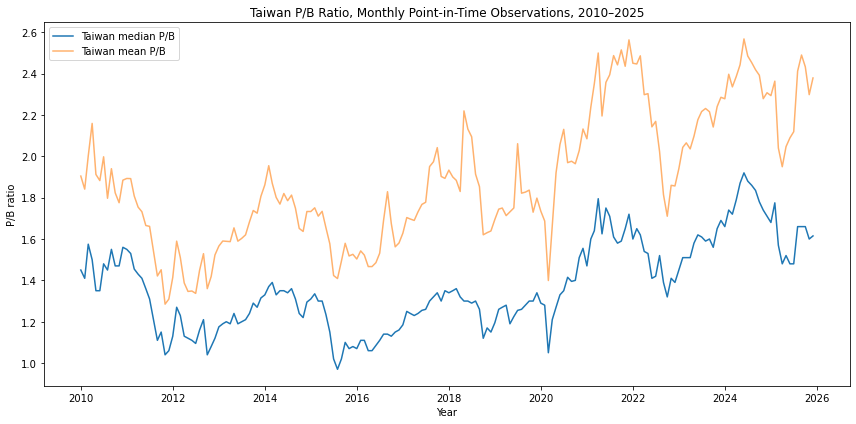

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    taiwan_monthly["date"],
    taiwan_monthly["median_pbr"],
    label="Taiwan median P/B"
)

plt.plot(
    taiwan_monthly["date"],
    taiwan_monthly["mean_pbr"],
    label="Taiwan mean P/B",
    alpha=0.6
)

plt.title("Taiwan P/B Ratio, Monthly Point-in-Time Observations, 2010–2025")
plt.xlabel("Year")
plt.ylabel("P/B ratio")
plt.legend()
plt.tight_layout()

plt.savefig(output_path / "taiwan_pbr_monthly_2010_2025.png", dpi=300)
plt.show()

# Investors

In [1]:
import zipfile
import re
import io
from pathlib import Path

import pandas as pd

In [23]:
zip_path = Path("Trading_investor.zip")

output_path = Path("data_clean/investors")
output_path.mkdir(exist_ok=True)

In [3]:
records = []
all_dfs = []
failed_files = []

with zipfile.ZipFile(zip_path) as z:
    file_names = sorted([
        name for name in z.namelist()
        if name.lower().endswith(".xlsx")
    ])

    print("Number of Excel files found:", len(file_names))

    for name in file_names:
        file_short_name = Path(name).name

        year_match = re.search(r"(\d{4})\.xlsx$", file_short_name)

        if year_match is None:
            failed_files.append({
                "file": file_short_name,
                "reason": "No year found in filename"
            })
            continue

        year = int(year_match.group(1))

        try:
            file_data = z.read(name)

            df = pd.read_excel(
                io.BytesIO(file_data),
                sheet_name=0
            )

            df["year"] = year
            df["source_file"] = file_short_name

            all_dfs.append(df)

            records.append({
                "file": file_short_name,
                "year": year,
                "rows": len(df),
                "columns": " | ".join(df.columns.astype(str))
            })

        except Exception as e:
            failed_files.append({
                "file": file_short_name,
                "reason": str(e)
            })

print("Successfully read files:", len(all_dfs))
print("Failed files:", len(failed_files))

Number of Excel files found: 16
Successfully read files: 16
Failed files: 0


/home/jupyter-smsorokina@edu.hse-4bc37/.local/lib/python3.8/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/jupyter-smsorokina@edu.hse-4bc37/.local/lib/python3.8/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/jupyter-smsorokina@edu.hse-4bc37/.local/lib/python3.8/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/jupyter-smsorokina@edu.hse-4bc37/.local/lib/python3.8/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openp

In [5]:
trading_raw = pd.concat(all_dfs, ignore_index=True)

trading_raw

,Investor type,Trading volume_Sell,Trading volume_Buy,Trading volume_Net Buying,Trading value_Sell,Trading value_Buy,Trading value_Net Buying,year,source_file
0,Financial investment,1282391,1302075,19684,62898208,63917671,1019463,2010,Trading_investor_2010.xlsx
1,Insurance,894829,894459,-370,38798430,39292376,493947,2010,Trading_investor_2010.xlsx
2,Investment trust,2723402,2443838,-279564,131640226,112949723,-18690504,2010,Trading_investor_2010.xlsx
3,Private equity funds,469278,446237,-23041,22068428,20015391,-2053037,2010,Trading_investor_2010.xlsx
4,Bank,381596,299855,-81741,15680002,14238068,-1441935,2010,Trading_investor_2010.xlsx
...,...,...,...,...,...,...,...,...,...
203,Other corporations,1157530,1344662,187133,33601197,44965028,11363831,2025,Trading_investor_2025.xlsx
204,Individuals,72799904,72327794,-472111,1378689799,1352322306,-26367492,2025,Trading_investor_2025.xlsx
205,Foreigners,24461317,24481003,19686,1022335677,1017681060,-4654617,2025,Trading_investor_2025.xlsx
206,Other foreigners,286922,285836,-1087,4693556,4659192,-34364,2025,Trading_investor_2025.xlsx


In [6]:
trading = trading_raw.rename(columns={
    "Investor type": "investor_type",
    "Trading volume_Sell": "volume_sell",
    "Trading volume_Buy": "volume_buy",
    "Trading volume_Net Buying": "volume_net_buying",
    "Trading value_Sell": "value_sell",
    "Trading value_Buy": "value_buy",
    "Trading value_Net Buying": "value_net_buying"
})

In [7]:
trading["investor_type"] = (
    trading["investor_type"]
    .astype(str)
    .str.strip()
)

In [8]:
numeric_cols = [
    "volume_sell",
    "volume_buy",
    "volume_net_buying",
    "value_sell",
    "value_buy",
    "value_net_buying"
]

for col in numeric_cols:
    trading[col] = pd.to_numeric(trading[col], errors="coerce")

In [9]:
trading = trading.sort_values(["year", "investor_type"]).reset_index(drop=True)

trading.head()

,investor_type,volume_sell,volume_buy,volume_net_buying,value_sell,value_buy,value_net_buying,year,source_file
0,Bank,381596,299855,-81741,15680002,14238068,-1441935,2010,Trading_investor_2010.xlsx
1,Financial investment,1282391,1302075,19684,62898208,63917671,1019463,2010,Trading_investor_2010.xlsx
2,Foreigners,6084217,6282120,197902,273756968,295330075,21573107,2010,Trading_investor_2010.xlsx
3,"Government pension funds, etc.",1305039,1531723,226684,59432241,68126037,8693796,2010,Trading_investor_2010.xlsx
4,Individuals,80985446,81157235,171789,772747422,767363640,-5383782,2010,Trading_investor_2010.xlsx


In [10]:
coverage = (
    trading
    .groupby("year")
    .agg(
        investor_types=("investor_type", "nunique"),
        rows=("investor_type", "count"),
        total_value_sell=("value_sell", "sum"),
        total_value_buy=("value_buy", "sum"),
        total_value_net_buying=("value_net_buying", "sum")
    )
    .reset_index()
)

coverage

,year,investor_types,rows,total_value_sell,total_value_buy,total_value_net_buying
0,2010,13,13,3156221189,3143711051,-12510139
1,2011,13,13,3813486314,3825438001,11951688
2,2012,13,13,2684811608,2688445693,3634085
3,2013,13,13,2202456012,2207514181,5058165
4,2014,13,13,2182899949,2182206564,-693384
5,2015,13,13,2907258827,2906794247,-464583
6,2016,13,13,2448854931,2443645803,-5209127
7,2017,13,13,2861425117,2858999091,-2426027
8,2018,13,13,3527855555,3524966180,-2889374
9,2019,13,13,2734253063,2743108411,8855349


In [11]:
def classify_investor_type(x):
    if x in [
        "Financial investment",
        "Insurance",
        "Investment trust",
        "Private equity funds",
        "Bank",
        "Other finances",
        "Government pension funds, etc.",
        "Subtotal-Institutions"
    ]:
        return "Institutions"

    elif x == "Individuals":
        return "Individuals"

    elif x == "Foreigners":
        return "Foreigners"

    elif x == "Other corporations":
        return "Other corporations"

    elif x == "Other foreigners":
        return "Other foreigners"

    elif x == "Total":
        return "Total"

    else:
        return "Other"

In [12]:
trading["investor_group"] = trading["investor_type"].apply(classify_investor_type)

In [13]:
trading[["investor_type", "investor_group"]].drop_duplicates().sort_values("investor_group")

,investor_type,investor_group
2,Foreigners,Foreigners
4,Individuals,Individuals
0,Bank,Institutions
1,Financial investment,Institutions
3,"Government pension funds, etc.",Institutions
5,Insurance,Institutions
6,Investment trust,Institutions
8,Other finances,Institutions
10,Private equity funds,Institutions
11,Subtotal-Institutions,Institutions


In [14]:
main_investor_types = [
    "Subtotal-Institutions",
    "Individuals",
    "Foreigners",
    "Other corporations",
    "Other foreigners"
]

trading_main = trading[
    trading["investor_type"].isin(main_investor_types)
].copy()

trading_main.head()

,investor_type,volume_sell,volume_buy,volume_net_buying,value_sell,value_buy,value_net_buying,year,source_file,investor_group
2,Foreigners,6084217,6282120,197902,273756968,295330075,21573107,2010,Trading_investor_2010.xlsx,Foreigners
4,Individuals,80985446,81157235,171789,772747422,767363640,-5383782,2010,Trading_investor_2010.xlsx,Individuals
7,Other corporations,1077531,906984,-170548,26473034,22957292,-3515742,2010,Trading_investor_2010.xlsx,Other corporations
9,Other foreigners,185732,172723,-13009,2486824,2323379,-163445,2010,Trading_investor_2010.xlsx,Other foreigners
11,Subtotal-Institutions,7262781,7076647,-186135,335097564,322587426,-12510138,2010,Trading_investor_2010.xlsx,Institutions


In [15]:
label_map = {
    "Subtotal-Institutions": "Domestic institutions",
    "Individuals": "Individuals",
    "Foreigners": "Foreigners",
    "Other corporations": "Other corporations",
    "Other foreigners": "Other foreigners"
}

trading_main["investor_group_clean"] = trading_main["investor_type"].map(label_map)

In [16]:
trading_yearly_main = trading_main[
    [
        "year",
        "investor_group_clean",
        "volume_sell",
        "volume_buy",
        "volume_net_buying",
        "value_sell",
        "value_buy",
        "value_net_buying"
    ]
].copy()

trading_yearly_main = trading_yearly_main.sort_values(
    ["year", "investor_group_clean"]
).reset_index(drop=True)

trading_yearly_main.head()

,year,investor_group_clean,volume_sell,volume_buy,volume_net_buying,value_sell,value_buy,value_net_buying
0,2010,Domestic institutions,7262781,7076647,-186135,335097564,322587426,-12510138
1,2010,Foreigners,6084217,6282120,197902,273756968,295330075,21573107
2,2010,Individuals,80985446,81157235,171789,772747422,767363640,-5383782
3,2010,Other corporations,1077531,906984,-170548,26473034,22957292,-3515742
4,2010,Other foreigners,185732,172723,-13009,2486824,2323379,-163445


In [17]:
institutional_subtypes = [
    "Financial investment",
    "Insurance",
    "Investment trust",
    "Private equity funds",
    "Bank",
    "Other finances",
    "Government pension funds, etc."
]

trading_institutional_detail = trading[
    trading["investor_type"].isin(institutional_subtypes)
].copy()

trading_institutional_detail = trading_institutional_detail.sort_values(
    ["year", "investor_type"]
).reset_index(drop=True)

trading_institutional_detail.head()

,investor_type,volume_sell,volume_buy,volume_net_buying,value_sell,value_buy,value_net_buying,year,source_file,investor_group
0,Bank,381596,299855,-81741,15680002,14238068,-1441935,2010,Trading_investor_2010.xlsx,Institutions
1,Financial investment,1282391,1302075,19684,62898208,63917671,1019463,2010,Trading_investor_2010.xlsx,Institutions
2,"Government pension funds, etc.",1305039,1531723,226684,59432241,68126037,8693796,2010,Trading_investor_2010.xlsx,Institutions
3,Insurance,894829,894459,-370,38798430,39292376,493947,2010,Trading_investor_2010.xlsx,Institutions
4,Investment trust,2723402,2443838,-279564,131640226,112949723,-18690504,2010,Trading_investor_2010.xlsx,Institutions


In [18]:
trading_wide = (
    trading_yearly_main
    .pivot_table(
        index="year",
        columns="investor_group_clean",
        values="value_net_buying",
        aggfunc="sum"
    )
    .reset_index()
)

# Clean column names
trading_wide.columns = [
    str(col)
    .lower()
    .replace(" ", "_")
    .replace("-", "_")
    for col in trading_wide.columns
]

trading_wide.head()

,year,domestic_institutions,foreigners,individuals,other_corporations,other_foreigners
0,2010,-12510138,21573107,-5383782,-3515742,-163445
1,2011,11951687,-7995487,-1819936,-1989898,-146366
2,2012,3634087,17462138,-15550008,-4772565,-773653
3,2013,5058166,3411143,-5639031,-2613444,-216833
4,2014,-693384,4834818,-2836278,-1146947,-158209


In [19]:
trading_main["value_total_trading"] = (
    trading_main["value_sell"] + trading_main["value_buy"]
)

trading_main["volume_total_trading"] = (
    trading_main["volume_sell"] + trading_main["volume_buy"]
)

trading_main["net_buying_ratio_value"] = (
    trading_main["value_net_buying"] / trading_main["value_total_trading"]
)

trading_main["net_buying_ratio_volume"] = (
    trading_main["volume_net_buying"] / trading_main["volume_total_trading"]
)

In [20]:
trading_desc = (
    trading_main
    .groupby("investor_group_clean")
    .agg(
        observations=("year", "count"),
        mean_value_net_buying=("value_net_buying", "mean"),
        median_value_net_buying=("value_net_buying", "median"),
        std_value_net_buying=("value_net_buying", "std"),
        min_value_net_buying=("value_net_buying", "min"),
        max_value_net_buying=("value_net_buying", "max"),
        mean_net_buying_ratio_value=("net_buying_ratio_value", "mean")
    )
    .reset_index()
)

trading_desc

,investor_group_clean,observations,mean_value_net_buying,median_value_net_buying,std_value_net_buying,min_value_net_buying,max_value_net_buying,mean_net_buying_ratio_value
0,Domestic institutions,16,-2.998739e+06,-578983.5,1.409371e+07,-38626326,19692643,-0.002641
1,Foreigners,16,-4.455562e+03,1114889.0,1.302958e+07,-25601111,21573107,0.002880
2,Individuals,16,1.887079e+06,-5369214.0,2.366303e+07,-26367492,65902118,-0.002025
3,Other corporations,16,1.334474e+06,1742652.0,4.029636e+06,-4772565,11363831,0.027483
4,Other foreigners,16,-2.183578e+05,-152287.5,2.851672e+05,-854167,194966,-0.054479


In [21]:
trading_main["value_up_period"] = trading_main["year"].apply(
    lambda x: "Post-Value-Up" if x >= 2024 else "Pre-Value-Up"
)

In [22]:
value_up_trading_desc = (
    trading_main
    .groupby(["value_up_period", "investor_group_clean"])
    .agg(
        observations=("year", "count"),
        mean_value_net_buying=("value_net_buying", "mean"),
        median_value_net_buying=("value_net_buying", "median"),
        mean_net_buying_ratio_value=("net_buying_ratio_value", "mean")
    )
    .reset_index()
)

value_up_trading_desc

,value_up_period,investor_group_clean,observations,mean_value_net_buying,median_value_net_buying,mean_net_buying_ratio_value
0,Post-Value-Up,Domestic institutions,2,1.060906e+07,10609060.5,0.009416
1,Post-Value-Up,Foreigners,2,-1.687666e+06,-1687666.0,-0.000692
2,Post-Value-Up,Individuals,2,-1.586107e+07,-15861069.0,-0.005784
3,Post-Value-Up,Other corporations,2,6.937896e+06,6937895.5,0.094571
4,Post-Value-Up,Other foreigners,2,1.779000e+03,1779.0,0.000214
5,Pre-Value-Up,Domestic institutions,14,-4.942711e+06,-1559705.5,-0.004363
6,Pre-Value-Up,Foreigners,14,2.360031e+05,2180818.0,0.003391
7,Pre-Value-Up,Individuals,14,4.422528e+06,-4110030.0,-0.001488
8,Pre-Value-Up,Other corporations,14,5.339851e+05,1560501.5,0.017899
9,Pre-Value-Up,Other foreigners,14,-2.498059e+05,-160827.0,-0.062292


In [24]:
trading.to_csv(
    output_path / "trading_investor_2010_2025_full_clean.csv",
    index=False
)

trading_main.to_csv(
    output_path / "trading_investor_2010_2025_main_groups.csv",
    index=False
)

trading_institutional_detail.to_csv(
    output_path / "trading_investor_2010_2025_institutional_detail.csv",
    index=False
)

trading_wide.to_csv(
    output_path / "trading_investor_2010_2025_wide_net_buying.csv",
    index=False
)

trading_desc.to_csv(
    output_path / "trading_investor_descriptive_statistics.csv",
    index=False
)

value_up_trading_desc.to_csv(
    output_path / "trading_investor_pre_post_value_up_descriptive_statistics.csv",
    index=False
)

pd.DataFrame(records).to_csv(
    output_path / "trading_investor_file_coverage.csv",
    index=False
)

pd.DataFrame(failed_files).to_csv(
    output_path / "trading_investor_failed_files.csv",
    index=False
)

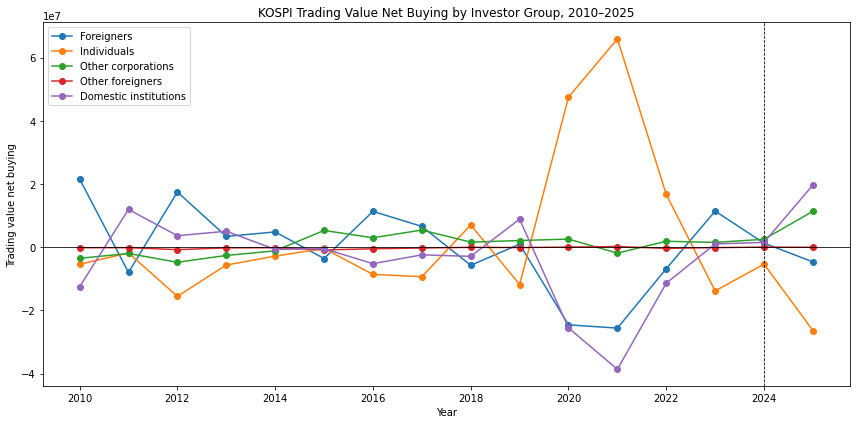

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for group in trading_main["investor_group_clean"].unique():
    subset = trading_main[trading_main["investor_group_clean"] == group]
    plt.plot(subset["year"], subset["value_net_buying"], marker="o", label=group)

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(2024, color="black", linestyle="--", linewidth=0.8)

plt.title("KOSPI Trading Value Net Buying by Investor Group, 2010–2025")
plt.xlabel("Year")
plt.ylabel("Trading value net buying")
plt.legend()
plt.tight_layout()

plt.savefig(output_path / "trading_value_net_buying_by_investor_group_check.png", dpi=300)
plt.show()

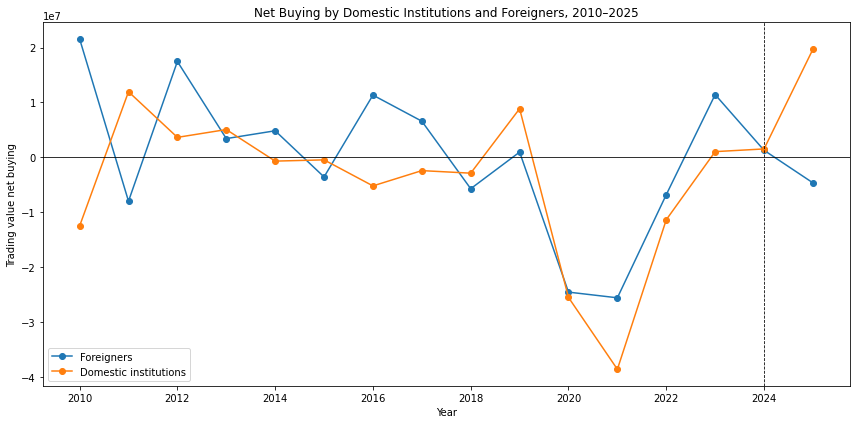

In [26]:
plot_subset = trading_main[
    trading_main["investor_group_clean"].isin([
        "Domestic institutions",
        "Foreigners"
    ])
]

plt.figure(figsize=(12, 6))

for group in plot_subset["investor_group_clean"].unique():
    subset = plot_subset[plot_subset["investor_group_clean"] == group]
    plt.plot(subset["year"], subset["value_net_buying"], marker="o", label=group)

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(2024, color="black", linestyle="--", linewidth=0.8)

plt.title("Net Buying by Domestic Institutions and Foreigners, 2010–2025")
plt.xlabel("Year")
plt.ylabel("Trading value net buying")
plt.legend()
plt.tight_layout()

plt.savefig(output_path / "domestic_institutions_foreigners_net_buying_check.png", dpi=300)
plt.show()